In [27]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
def dp_results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        e = config["e"]
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "sampling", "e", "b", "test_mae"])

# RQ1: Does Meta Learning improve the accuracy-privacy trade-off? (MetaMF vs. NoMetaMF)

In [57]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_df = dp_results_to_df(meta_results, dataset="ml1m", sampling_method="random", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_df = dp_results_to_df(nometa_results, dataset="ml1m", sampling_method="random", rec_method="NoMetaMF")

results_df = pd.concat([meta_results_df, nometa_results_df]).reset_index(drop=True)
results_df.head()

,dataset,recsys,sampling,e,b,test_mae
0,ml1m,MetaMF,random,3.0,0.0,0.692591
1,ml1m,MetaMF,random,3.0,0.2,0.692166
2,ml1m,MetaMF,random,3.0,0.4,0.691901
3,ml1m,MetaMF,random,3.0,0.6,0.690709
4,ml1m,MetaMF,random,3.0,0.8,0.683734


Text(0, 0.5, 'MAE')

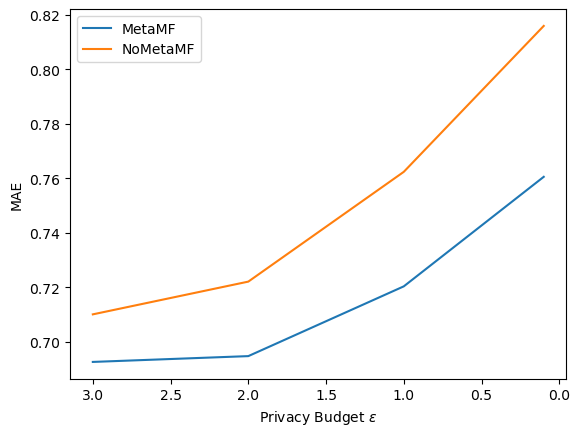

In [58]:
meta = results_df[(results_df["recsys"] == "MetaMF") & (results_df["b"] == 0)]
plt.plot(meta["e"], meta["test_mae"], label="MetaMF")

nometa = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 0)]
plt.plot(nometa["e"], nometa["test_mae"], label="NoMetaMF")

plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel("MAE")

Text(0, 0.5, '$\\Delta$MAE in $\\%$')

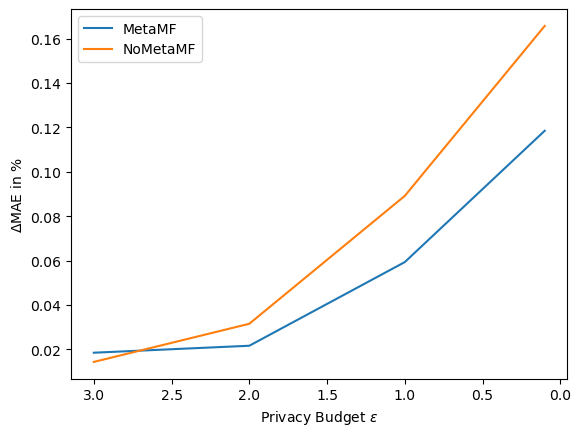

In [59]:
meta = results_df[(results_df["recsys"] == "MetaMF") & (results_df["b"] == 0)]
plt.plot(meta["e"], (meta["test_mae"] - 0.68) / 0.68, label="MetaMF")

nometa = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 0)]
plt.plot(nometa["e"], (nometa["test_mae"] - 0.7) / 0.7, label="NoMetaMF")

plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel(r"$\Delta$MAE in $\%$")

# RQ2: How can sampling improve the trade-off further?

In [95]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_df = dp_results_to_df(meta_results, dataset="ml1m", sampling_method="random", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_df = dp_results_to_df(nometa_results, dataset="ml1m", sampling_method="random", rec_method="NoMetaMF")
with open(PATH + "MetaMF.ister_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_df = dp_results_to_df(meta_results, dataset="ml1m", sampling_method="ister", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_df = dp_results_to_df(nometa_results, dataset="ml1m", sampling_method="ister", rec_method="NoMetaMF")


results_df = pd.concat([meta_results_random_df, nometa_results_random_df, meta_results_ister_df, nometa_results_ister_df]).reset_index(drop=True)
results_df.head()

,dataset,recsys,sampling,e,b,test_mae
0,ml1m,MetaMF,random,3.0,0.0,0.692591
1,ml1m,MetaMF,random,3.0,0.2,0.692166
2,ml1m,MetaMF,random,3.0,0.4,0.691901
3,ml1m,MetaMF,random,3.0,0.6,0.690709
4,ml1m,MetaMF,random,3.0,0.8,0.683734


Text(0, 0.5, 'MAE')

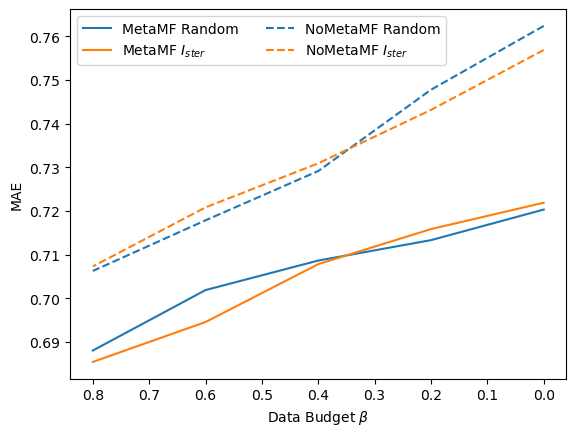

In [103]:
meta_random = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "random") & (results_df["e"] == 1)]
meta_ister = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "ister") & (results_df["e"] == 1)]
plt.plot(meta_random["b"], meta_random["test_mae"], label="MetaMF Random", c="C0")
plt.plot(meta_ister["b"], meta_ister["test_mae"], label=r"MetaMF $I_{ster}$", c="C1")

nometa_random = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "random") & (results_df["e"] == 1)]
nometa_ister = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "ister") & (results_df["e"] == 1)]
plt.plot(nometa_random["b"], nometa_random["test_mae"], label="NoMetaMF Random", c="C0", linestyle="dashed")
plt.plot(nometa_ister["b"], nometa_ister["test_mae"], label=r"NoMetaMF $I_{ster}$", c="C1", linestyle="dashed")

plt.gca().invert_xaxis()

plt.legend(ncols=2)
plt.xlabel(r"Data Budget $\beta$")
plt.ylabel("MAE")